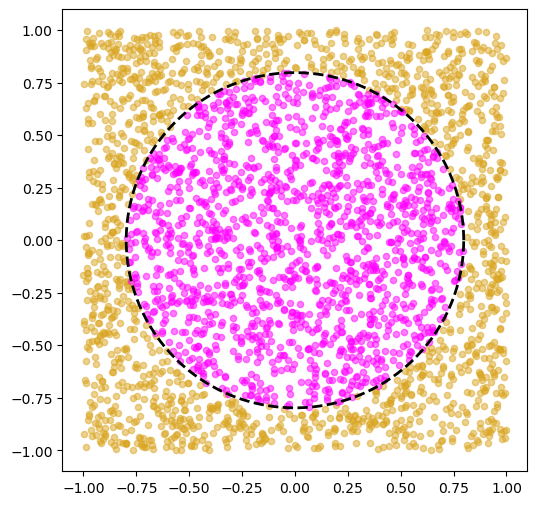

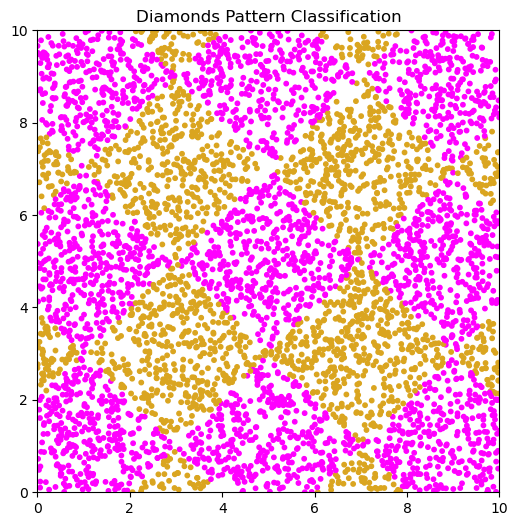

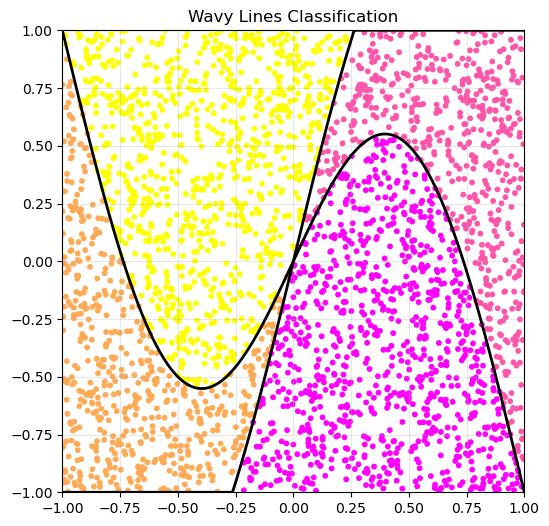

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sys
import warnings
warnings.filterwarnings('ignore') 
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from scipy.optimize import minimize

from datasets import circle, plot_circle, diamond, plot_diamond, wavy_lines, plot_wavy
import single_qubit
from single_qubit import *
import importlib
importlib.reload(single_qubit)
import plotting
from plotting import *
importlib.reload(plotting)
import pickle

# Simple cost function

# Circle

In [2]:
all_losses_circle = {}
all_train_accuracies_circle = {}
all_test_accuracies_circle = {}

In [3]:
data, (centers, radii) = circle(samples=4200, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.95,
    random_state=42,
    stratify=y) #stratify allows to have a balance amount of labels in each split


print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Test: {len(x_test)} samples")

Train/Test datasets
Train: 210 samples
Test: 3990 samples


### 1 layer

In [4]:
n_layers = 1
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)


[[3.13553675 5.85300733 3.66518877]] [[0.53838419 0.45448273 0.20928776]] [0.00371966 0.24150623]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 76.722227
Iteration 2, cost: 74.246969
Iteration 3, cost: 72.306800
Iteration 4, cost: 71.250837
Iteration 5, cost: 68.852227
Iteration 6, cost: 66.988610
Iteration 7, cost: 65.359248
Iteration 8, cost: 63.146509
Iteration 9, cost: 61.846771
Iteration 10, cost: 61.841987
Iteration 11, cost: 61.841948
Iteration 12, cost: 61.841933
Iteration 13, cost: 61.841933
Iteration 14, cost: 61.841933
Iteration 15, cost: 61.841933
[[3.32009461 5.85300634 3.66518958]] [[0.30489727 3.25367633 0.20928776]]
Optimization success: True
Final cost: 61.841933
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [5]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7338


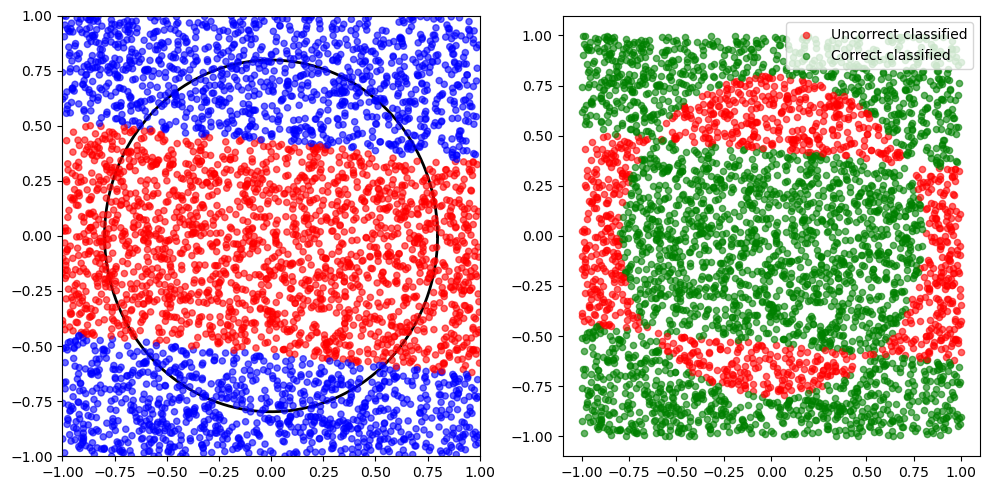

In [6]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 2 layers

In [19]:
n_layers = 2
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[3.20268514 2.38735879 2.8179158 ]
 [6.16159448 2.20082621 2.8411492 ]] [[0.13351555 0.04795773 0.77540951]
 [0.57068318 0.76070481 0.1498628 ]] [0.57182877 0.25364247]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 81.492985
Iteration 2, cost: 76.120475
Iteration 3, cost: 70.285338
Iteration 4, cost: 68.126859
Iteration 5, cost: 66.705450
Iteration 6, cost: 65.931922
Iteration 7, cost: 64.103737
Iteration 8, cost: 62.244911
Iteration 9, cost: 60.779201
Iteration 10, cost: 60.534241
Iteration 11, cost: 60.403964
Iteration 12, cost: 60.333772
Iteration 13, cost: 60.264951
Iteration 14, cost: 60.245137
Iteration 15, cost: 60.230759
Iteration 16, cost: 60.229608
Iteration 17, cost: 60.229117
Iteration 18, cost: 60.229092
Iteration 19, cost: 60.229091
Iteration 20, cost: 60.229091
Iteration 21, cost: 60.229091
Iteration 22, cost: 60.229091
Iteration 23, cost: 60.229091
[[3.22122507 3.00546749 2.81791514]
 [6.43123024 2.20082624 3.45925857]] [[ 0.01607895 -0.35417055  0.77540951]
 [

In [20]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7439


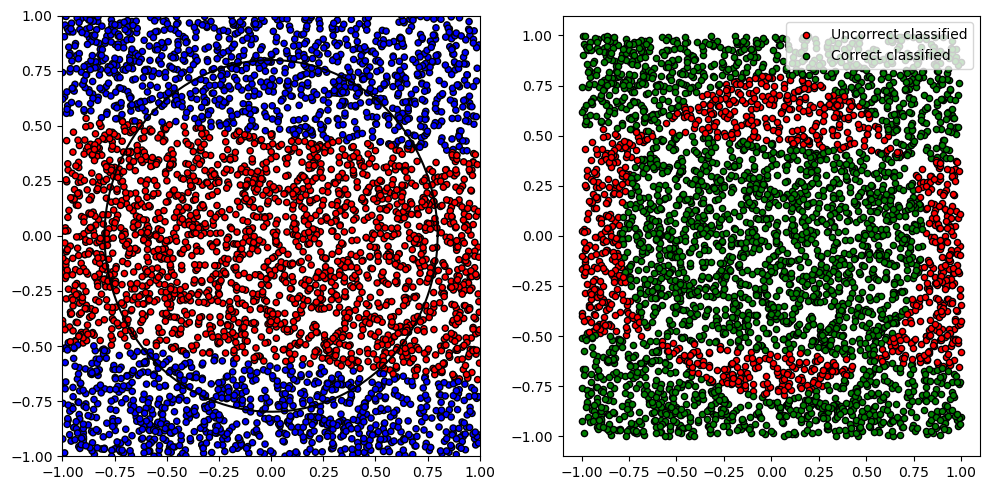

In [ ]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 4 layers

In [22]:
# 16 mins
n_layers = 4
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[1.43295466 0.07242008 0.81895492]
 [1.94318885 0.73437091 6.19433127]
 [1.93919612 0.81884951 1.25087106]
 [3.69264829 0.40239733 5.41883345]] [[0.96149968 0.24674742 0.45009527]
 [0.02213445 0.64071022 0.41392606]
 [0.27005847 0.20683711 0.65402308]
 [0.41621703 0.17965929 0.68910908]] [0.56507228 0.85867205]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 73.674446
Iteration 2, cost: 72.833657
Iteration 3, cost: 70.947309
Iteration 4, cost: 70.192200
Iteration 5, cost: 68.780149
Iteration 6, cost: 66.164385
Iteration 7, cost: 63.011064
Iteration 8, cost: 62.563908
Iteration 9, cost: 62.446510
Iteration 10, cost: 62.319878
Iteration 11, cost: 62.172084
Iteration 12, cost: 62.127820
Iteration 13, cost: 62.091063
Iteration 14, cost: 62.028235
Iteration 15, cost: 62.003962
Iteration 16, cost: 61.986809
Iteration 17, cost: 61.960025
Iteration 18, cost: 61.934068
Iteration 19, cost: 61.889613
Iteration 20, cost: 61.872421
Iteration 21, cost: 61.859577
Iteration 22, cost: 61.841639


In [23]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7867


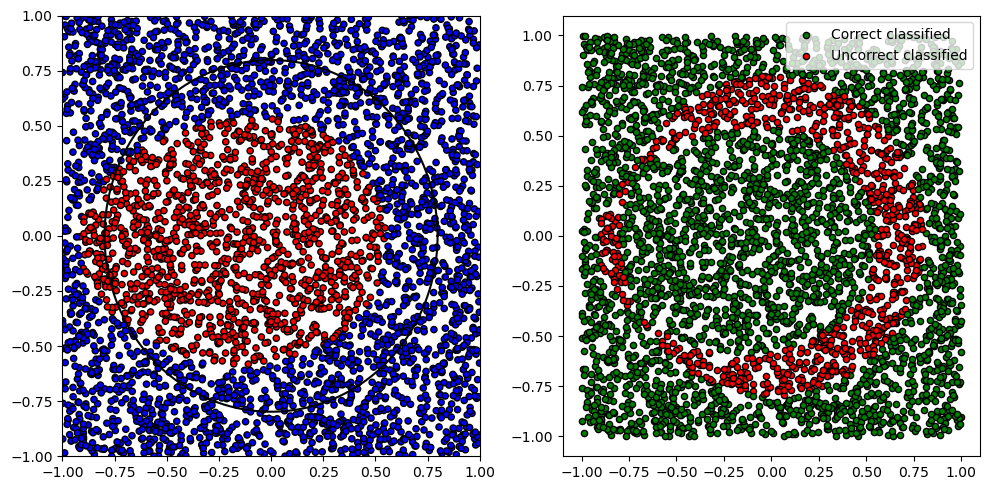

In [30]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 8 layers

In [ ]:
# 45 min
n_layers = 8
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[0.73812284 4.93648885 4.23183078]
 [0.72263503 4.3656874  2.77432344]
 [5.93751452 0.88977036 4.03904132]
 [2.40005141 6.01184388 2.07329341]
 [6.04559237 5.66420265 1.69886797]
 [5.04880189 6.25556569 1.58752846]
 [2.74435189 3.26839196 1.85310698]
 [0.09591182 1.38311283 1.77146169]] [[0.4435997  0.17110248 0.87325436]
 [0.70491113 0.08520048 0.65009245]
 [0.65365648 0.95622117 0.00302087]
 [0.24793245 0.92779148 0.93213392]
 [0.72058642 0.76576332 0.09148296]
 [0.51387583 0.23158299 0.18121804]
 [0.8103033  0.13503814 0.46865164]
 [0.93857824 0.18583206 0.97799342]] [0.99428799 0.55561715]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 70.099857
Iteration 2, cost: 63.777581
Iteration 3, cost: 56.602919
Iteration 4, cost: 51.637827
Iteration 5, cost: 49.767053
Iteration 6, cost: 48.923830
Iteration 7, cost: 46.659476
Iteration 8, cost: 44.700463
Iteration 9, cost: 42.547353
Iteration 10, cost: 41.481275
Iteration 11, cost: 39.908117
Iteration 12, cost: 38.768223
Iteration 13

In [32]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.9103


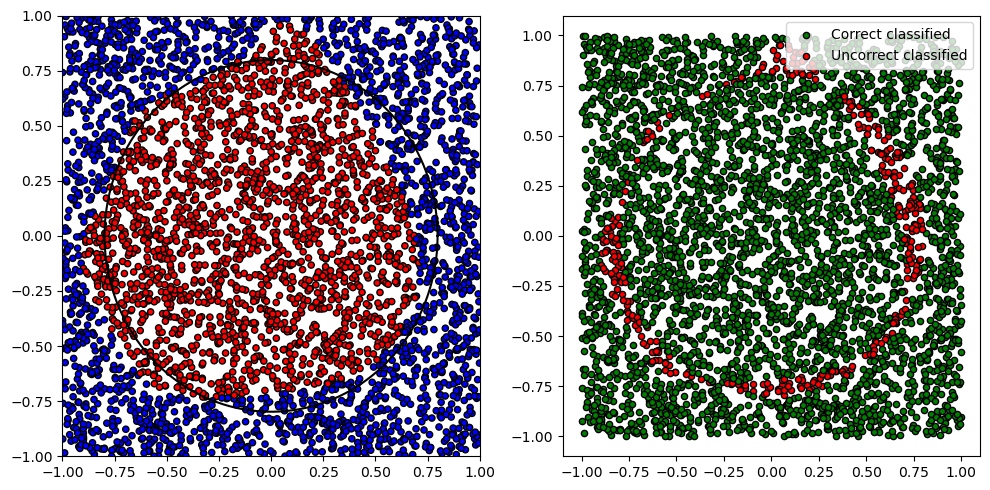

In [33]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 12 layers

### 16 layers

# Diamond

In [11]:
all_losses_diamond = {}
all_train_accuracies_diamond = {}
all_test_accuracies_diamond = {}

In [12]:
x_data, y_data, pattern_labels = diamond(samples=4200, limit=10, scale=4.0)
zeros = np.zeros(len(x_data))
x = np.column_stack((x_data, y_data, zeros))
y = pattern_labels

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.95,random_state=42,stratify=y)

print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Test: {len(x_test)} samples")

Train/Test datasets
Train: 210 samples
Test: 3990 samples


### 1 layer

In [13]:
n_layers = 1
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_diamond[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_diamond[n_layers] = np.mean(train_preds == y_train)

[[3.13553675 5.85300733 3.66518877]] [[0.53838419 0.45448273 0.20928776]] [0.00371966 0.24150623]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 89.142669
Iteration 2, cost: 88.284624
Iteration 3, cost: 87.533547
Iteration 4, cost: 87.309114
Iteration 5, cost: 86.580152
Iteration 6, cost: 85.363792
Iteration 7, cost: 84.642406
Iteration 8, cost: 84.592536
Iteration 9, cost: 84.592507
Iteration 10, cost: 84.592505
Iteration 11, cost: 84.592505
Iteration 12, cost: 84.592505
[[4.83813809 5.85300713 3.66518853]] [[3.28527152 1.36702173 0.20928776]]
Optimization success: True
Final cost: 84.592505
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [14]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_diamond[n_layers] = accuracy

Test accuracy: 0.5807


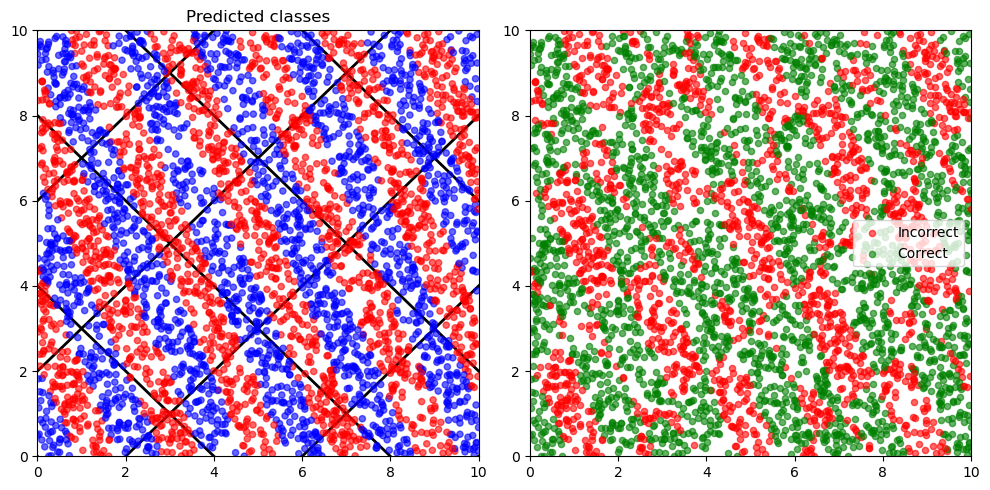

In [15]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_diamond(x_test, y_test, preds)

### 2 layers

In [16]:
n_layers = 2
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_diamond[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_diamond[n_layers] = np.mean(train_preds == y_train)

[[3.20268514 2.38735879 2.8179158 ]
 [6.16159448 2.20082621 2.8411492 ]] [[0.13351555 0.04795773 0.77540951]
 [0.57068318 0.76070481 0.1498628 ]] [0.57182877 0.25364247]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 108.292465
Iteration 2, cost: 105.452346
Iteration 3, cost: 101.937709
Iteration 4, cost: 93.086085
Iteration 5, cost: 91.813587
Iteration 6, cost: 91.068059
Iteration 7, cost: 89.462562
Iteration 8, cost: 88.053712
Iteration 9, cost: 87.354393
Iteration 10, cost: 86.403767
Iteration 11, cost: 85.477403
Iteration 12, cost: 85.394710
Iteration 13, cost: 85.355991
Iteration 14, cost: 85.272564
Iteration 15, cost: 85.070354
Iteration 16, cost: 84.475454
Iteration 17, cost: 83.726487
Iteration 18, cost: 83.008623
Iteration 19, cost: 81.043321
Iteration 20, cost: 79.809604
Iteration 21, cost: 78.504642
Iteration 22, cost: 78.241493
Iteration 23, cost: 77.858097
Iteration 24, cost: 77.765941
Iteration 25, cost: 77.495284
Iteration 26, cost: 77.448022
Iteration 27, cost: 7

In [17]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_diamond[n_layers] = accuracy

Test accuracy: 0.6887


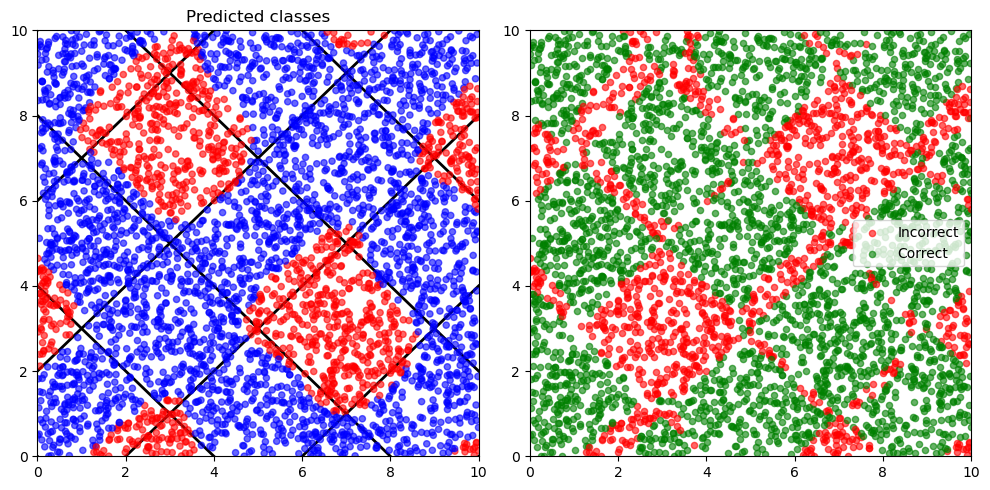

In [18]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_diamond(x_test, y_test, preds)

### 4 layers

In [ ]:
# 17 mins
n_layers = 4
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_diamond[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_diamond[n_layers] = np.mean(train_preds == y_train)

[[1.43295466 0.07242008 0.81895492]
 [1.94318885 0.73437091 6.19433127]
 [1.93919612 0.81884951 1.25087106]
 [3.69264829 0.40239733 5.41883345]] [[0.96149968 0.24674742 0.45009527]
 [0.02213445 0.64071022 0.41392606]
 [0.27005847 0.20683711 0.65402308]
 [0.41621703 0.17965929 0.68910908]] [0.56507228 0.85867205]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 97.442880
Iteration 2, cost: 95.866235
Iteration 3, cost: 95.289780
Iteration 4, cost: 94.400582
Iteration 5, cost: 90.656854
Iteration 6, cost: 88.865330
Iteration 7, cost: 86.968947
Iteration 8, cost: 85.951222
Iteration 9, cost: 84.961710
Iteration 10, cost: 84.466671
Iteration 11, cost: 83.737995
Iteration 12, cost: 83.374367
Iteration 13, cost: 82.720603
Iteration 14, cost: 82.481896
Iteration 15, cost: 82.271939
Iteration 16, cost: 81.985725
Iteration 17, cost: 81.810272
Iteration 18, cost: 81.750665
Iteration 19, cost: 81.610158
Iteration 20, cost: 81.546578
Iteration 21, cost: 81.346683
Iteration 22, cost: 81.080411


In [20]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_diamond[n_layers] = accuracy

Test accuracy: 0.7115


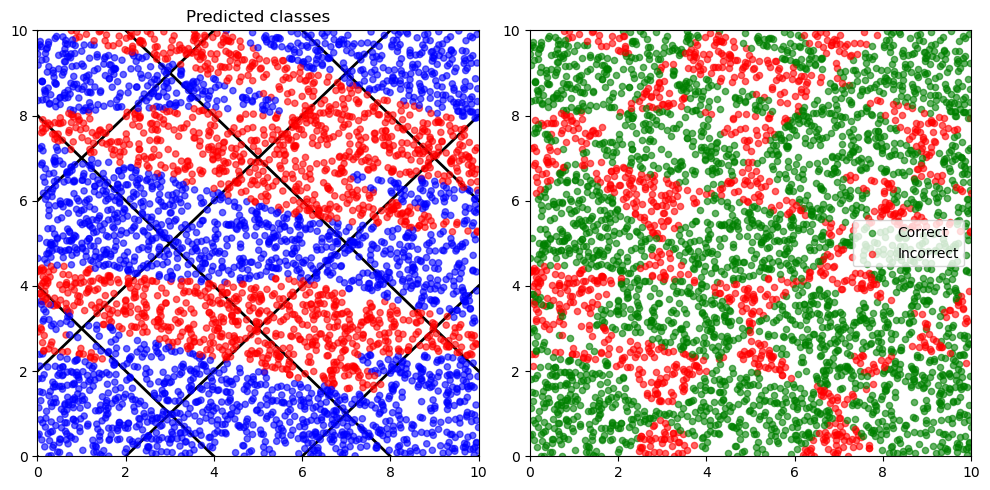

In [21]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_diamond(x_test, y_test, preds)

### 8 layers

### 12 layers

### 16 layers

In [23]:
print(all_losses_diamond)

{1: [89.1426686672491, 88.2846242352725, 87.53354712079117, 87.30911414639988, 86.58015221554774, 85.36379222300293, 84.6424059888347, 84.59253594020457, 84.59250680799069, 84.59250473020302, 84.5925047300981, 84.59250473009698], 2: [108.29246460361823, 105.45234589180008, 101.93770909394763, 93.08608536447312, 91.81358733512546, 91.06805923571937, 89.46256227173498, 88.05371211778152, 87.35439282074422, 86.40376652153371, 85.47740310868464, 85.39470969281808, 85.3559911930583, 85.27256435867567, 85.07035368108039, 84.47545431801265, 83.72648665630838, 83.00862337202676, 81.04332069025992, 79.80960374884265, 78.50464217378361, 78.2414930588186, 77.85809746500505, 77.76594123397608, 77.49528422974605, 77.44802193236535, 77.44325901289955, 77.44208112937484, 77.44147914260333, 77.43648034270335, 77.42914563365431, 77.41568325571484, 77.40226002649959, 77.3997441034649, 77.39443366558142, 77.39289447169885, 77.39281960104185, 77.39277224547102, 77.39272755377199, 77.39271677158965, 77.392

In [24]:
print(all_test_accuracies_diamond)

{1: np.float64(0.5807017543859649), 2: np.float64(0.6887218045112782), 4: np.float64(0.7115288220551379)}


In [25]:
print(all_train_accuracies_diamond)

{1: np.float64(0.6), 2: np.float64(0.7), 4: np.float64(0.7523809523809524)}


In [ ]:
# to save the data
data = {
    'losses': all_losses_diamond,
    'train_accuracies': all_train_accuracies_diamond,
    'test_accuracies': all_test_accuracies_diamond,
}

with open('diamond_results.pkl', 'wb') as f:
    pickle.dump(data, f)

In [ ]:
# to reload the data
with open('diamond_results.pkl', 'rb') as f:
    data = pickle.load(f)

all_losses_diamond = data['losses']
all_train_accuracies_diamond = data['train_accuracies']
all_test_accuracies_diamond = data['test_accuracies']

# Weighted cost function

# Circle

In [2]:
all_losses_circle_wcf = {}
all_train_accuracies_circle_wcf = {}
all_test_accuracies_circle_wcf = {}

In [3]:
data, (centers, radii) = circle(samples=4200, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.95,
    random_state=42,
    stratify=y) #stratify allows to have a balance amount of labels in each split


print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Test: {len(x_test)} samples")

Train/Test datasets
Train: 210 samples
Test: 3990 samples


### 1 layer

In [5]:
n_layers = 1
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = weighted_single_cost_function(params, n_layers, n_classes, x_train, y_train, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= weighted_single_cost_function,
    x0=params,
    args=(n_layers, n_classes, x_train, y_train, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, alpha_opt = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt, alpha_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle_wcf[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle_wcf[n_layers] = np.mean(train_preds == y_train)


[[3.20268514 2.38735879 2.8179158 ]] [[0.98064822 0.35027237 0.45218294]] [0.13351555 0.04795773]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 90.992096
Iteration 2, cost: 71.241015
Iteration 3, cost: 50.307302
Iteration 4, cost: 48.289321
Iteration 5, cost: 43.102693
Iteration 6, cost: 40.945109
Iteration 7, cost: 40.186703
Iteration 8, cost: 38.335070
Iteration 9, cost: 37.724096
Iteration 10, cost: 37.311905
Iteration 11, cost: 37.228178
Iteration 12, cost: 37.219019
Iteration 13, cost: 37.207680
Iteration 14, cost: 37.204269
Iteration 15, cost: 37.203523
Iteration 16, cost: 37.203457
Iteration 17, cost: 37.203457
Iteration 18, cost: 37.203456
Iteration 19, cost: 37.203456
Iteration 20, cost: 37.203456
Iteration 21, cost: 37.203456
[[3.36092043 2.38735887 2.81791569]] [[ 2.6821111  -0.22267148  0.45218294]] [[1.09191852]
 [0.86200219]]
Optimization success: True
Final cost: 37.203456
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [6]:
preds = single_qubit_predict_wcf(x_test, n_layers, n_classes, 
                theta_opt, w_opt, alpha_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle_wcf[n_layers] = accuracy

Test accuracy: 0.7393


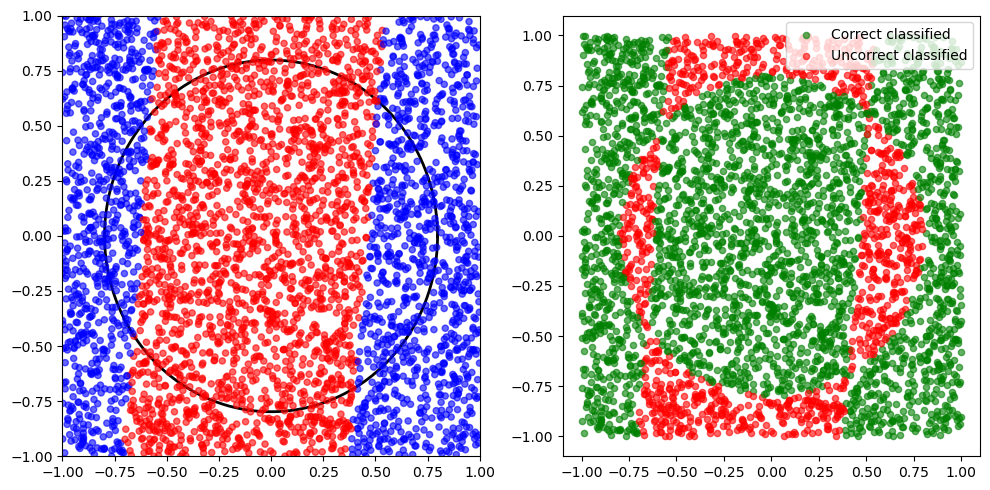

In [7]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 2 layers

In [8]:
n_layers = 2
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = weighted_single_cost_function(params, n_layers, n_classes, x_train, y_train, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= weighted_single_cost_function,
    x0=params,
    args=(n_layers, n_classes, x_train, y_train, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, alpha_opt = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt, alpha_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle_wcf[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle_wcf[n_layers] = np.mean(train_preds == y_train)


[[4.87204167 3.58570814 4.77964926]
 [0.94161574 3.59290613 1.59368267]] [[0.22806182 0.01152601 0.13034072]
 [0.30926811 0.11687876 0.98585844]] [0.30863265 0.13032395]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 73.335548
Iteration 2, cost: 55.457980
Iteration 3, cost: 51.479878
Iteration 4, cost: 50.593542
Iteration 5, cost: 49.853066
Iteration 6, cost: 48.255690
Iteration 7, cost: 47.255709
Iteration 8, cost: 45.050832
Iteration 9, cost: 41.919789
Iteration 10, cost: 41.705149
Iteration 11, cost: 41.590544
Iteration 12, cost: 41.485669
Iteration 13, cost: 39.617340
Iteration 14, cost: 37.920866
Iteration 15, cost: 37.706250
Iteration 16, cost: 35.413609
Iteration 17, cost: 32.327010
Iteration 18, cost: 29.477739
Iteration 19, cost: 26.146016
Iteration 20, cost: 24.989456
Iteration 21, cost: 24.312530
Iteration 22, cost: 21.974732
Iteration 23, cost: 20.610347
Iteration 24, cost: 18.850147
Iteration 25, cost: 18.149778
Iteration 26, cost: 17.792410
Iteration 27, cost: 17.7

In [9]:
preds = single_qubit_predict_wcf(x_test, n_layers, n_classes, 
                theta_opt, w_opt, alpha_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle_wcf[n_layers] = accuracy

Test accuracy: 0.8890


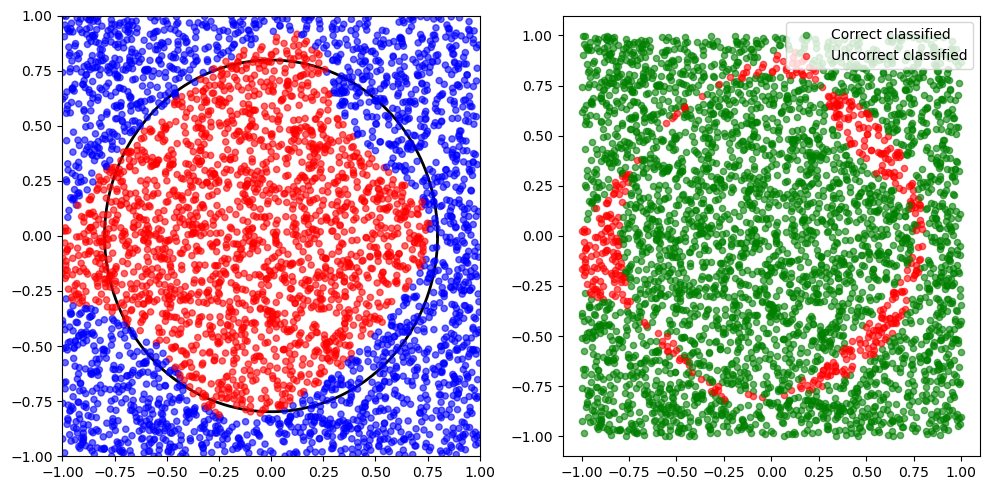

In [10]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 4 layers

In [ ]:
# 5 mins
n_layers = 4
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = weighted_single_cost_function(params, n_layers, n_classes, x_train, y_train, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= weighted_single_cost_function,
    x0=params,
    args=(n_layers, n_classes, x_train, y_train, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, alpha_opt = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt, alpha_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle_wcf[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle_wcf[n_layers] = np.mean(train_preds == y_train)


[[1.25087106 3.69264829 0.40239733]
 [5.41883345 6.04128066 1.55035977]
 [2.82803198 0.13907486 4.02570107]
 [2.60077413 1.69682739 1.29959589]] [[0.65402308 0.41621703 0.17965929]
 [0.68910908 0.56507228 0.85867205]
 [0.1174759  0.7856666  0.67351679]
 [0.11501094 0.69482073 0.44154729]] [0.94498479 0.14161135]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 80.915842
Iteration 2, cost: 64.033514
Iteration 3, cost: 45.946201
Iteration 4, cost: 36.461888
Iteration 5, cost: 35.799731
Iteration 6, cost: 35.598327
Iteration 7, cost: 34.594231
Iteration 8, cost: 34.273079
Iteration 9, cost: 33.920995
Iteration 10, cost: 33.590151
Iteration 11, cost: 32.967660
Iteration 12, cost: 31.513122
Iteration 13, cost: 30.570578
Iteration 14, cost: 29.480066
Iteration 15, cost: 28.322873
Iteration 16, cost: 22.839736
Iteration 17, cost: 19.874056
Iteration 18, cost: 16.979709
Iteration 19, cost: 15.449034
Iteration 20, cost: 14.938793
Iteration 21, cost: 14.684667
Iteration 22, cost: 14.348619


In [15]:
preds = single_qubit_predict_wcf(x_test, n_layers, n_classes, 
                theta_opt, w_opt, alpha_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle_wcf[n_layers] = accuracy

Test accuracy: 0.9338


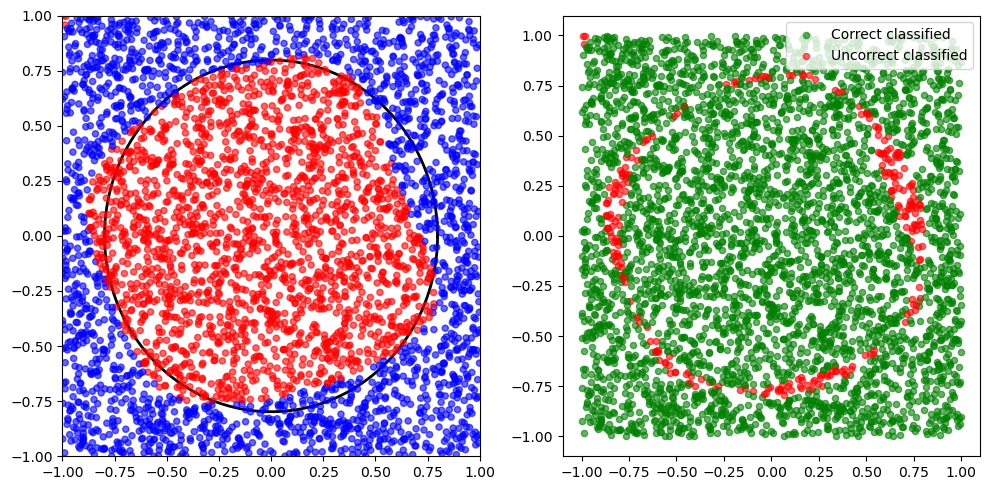

In [16]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 8 layers

In [ ]:
# 47 mins
n_layers = 8
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = weighted_single_cost_function(params, n_layers, n_classes, x_train, y_train, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= weighted_single_cost_function,
    x0=params,
    args=(n_layers, n_classes, x_train, y_train, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, alpha_opt = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt, alpha_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle_wcf[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle_wcf[n_layers] = np.mean(train_preds == y_train)


[[4.03904132 2.40005141 6.01184388]
 [2.07329341 6.04559237 5.66420265]
 [1.69886797 5.04880189 6.25556569]
 [1.58752846 2.74435189 3.26839196]
 [1.85310698 0.09591182 1.38311283]
 [1.77146169 2.78721913 1.07506858]
 [5.48681894 4.42908727 0.53533039]
 [4.08465134 4.10704477 6.00811483]] [[0.00302087 0.24793245 0.92779148]
 [0.93213392 0.72058642 0.76576332]
 [0.09148296 0.51387583 0.23158299]
 [0.18121804 0.8103033  0.13503814]
 [0.46865164 0.93857824 0.18583206]
 [0.97799342 0.99428799 0.55561715]
 [0.17014274 0.31610489 0.42449283]
 [0.30932422 0.28063558 0.97222971]] [0.15336483 0.73332791]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 46.926726
Iteration 2, cost: 39.192202
Iteration 3, cost: 35.033448
Iteration 4, cost: 31.275501
Iteration 5, cost: 29.156556
Iteration 6, cost: 27.269557
Iteration 7, cost: 25.330957
Iteration 8, cost: 23.305705
Iteration 9, cost: 21.002004
Iteration 10, cost: 19.029936
Iteration 11, cost: 17.288261
Iteration 12, cost: 15.595142
Iteration 13

In [21]:
preds = single_qubit_predict_wcf(x_test, n_layers, n_classes, 
                theta_opt, w_opt, alpha_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle_wcf[n_layers] = accuracy

Test accuracy: 0.9574


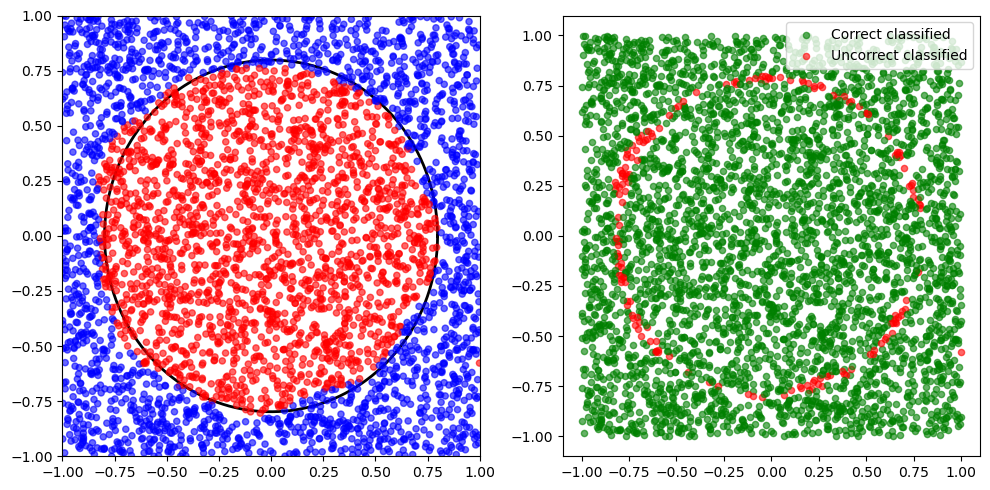

In [22]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 12 layers

### 16 layers

In [23]:
# to save the data
data = {
    'losses': all_losses_circle_wcf,
    'train_accuracies': all_train_accuracies_circle_wcf,
    'test_accuracies': all_test_accuracies_circle_wcf,
}

with open('circle_results_wcf.pkl', 'wb') as f:
    pickle.dump(data, f)

In [24]:
# to reload the data
with open('circle_results_wcf.pkl', 'rb') as f:
    data = pickle.load(f)

all_losses_diamond = data['losses']
all_train_accuracies_diamond = data['train_accuracies']
all_test_accuracies_diamond = data['test_accuracies']

print(all_test_accuracies_circle_wcf)

{1: np.float64(0.7393483709273183), 2: np.float64(0.8889724310776942), 4: np.float64(0.9338345864661655), 8: np.float64(0.9573934837092731)}
